# 💀 HALT! WHO GOES THERE?
### *A tiny neural network standing guard at the login gate*

New device from an unfamiliar country? Not today.
This model checks three things about a login — **when**, **where**, and **on what device** — and decides if it smells suspicious.

**Rule it learned:** 🚨 Suspicious only when the device is unknown *AND* the country is unusual — both, not just one.

---

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
from keras import Sequential
from keras.layers import Dense

df = pd.read_csv('HWGT.csv')
from sklearn.model_selection import train_test_split

# feature scaling FIRST, on the raw column in df
df['login_hour_scaled'] = (df['login_hour'] - df['login_hour'].min()) / (df['login_hour'].max() - df['login_hour'].min())

# NOW select your features, using the already-scaled column
X = df[['login_hour_scaled', 'country_match', 'device_known']]
y = df['suspicious']

# data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# train-test split with stratification to maintain class distribution
model = Sequential([
    Dense(units=1, activation='sigmoid', input_shape=(3,))
])
# compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
# train the model - now with class_weight to handle imbalance, and more epochs
model.fit(
    X_train, y_train,
    epochs=300,
    verbose=0,
    class_weight={0: 1, 1: 8}
)

# NEW: check real performance on the held-out test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}, Test accuracy: {accuracy:.4f}")

predictions = model.predict(X_train)
print("Predictions:", predictions[:10])  # just first 10 to keep output readable

user = input("Enter login hour (0-23), country match (0/1), device known (0/1): ")
raw_inputs = [int(x) for x in user.split()]
scaled_hour = raw_inputs[0] / 23  # match how login_hour_scaled was created
user_inputs = [scaled_hour, raw_inputs[1], raw_inputs[2]]
user_prediction = model.predict(np.array([user_inputs]))
probability = user_prediction[0][0]
final_answer = 1 if probability > 0.5 else 0
print(f"Prediction for inputs {user_inputs}: {final_answer} (confidence: {probability:.4f})")

/home/malaika/code/ML/EXHAUSTED/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test loss: 0.5225, Test accuracy: 0.7833
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Predictions: [[0.45340154]
 [0.28204542]
 [0.4562615 ]
 [0.2891046 ]
 [0.2727977 ]
 [0.26374197]
 [0.49940145]
 [0.6614109 ]
 [0.25488135]
 [0.68921703]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Prediction for inputs [0.782608695652174, 0, 0]: 1 (confidence: 0.8257)


## The Guard Stopped Guessing
 #### Loss flatlines by epoch 50 — decision made, gate secured.

Epoch 1/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8107 - loss: 0.5110
Epoch 2/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8336 - loss: 0.4765
Epoch 3/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8336 - loss: 0.4466
Epoch 4/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8336 - loss: 0.4221
Epoch 5/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8336 - loss: 0.4019
Epoch 6/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8471 - loss: 0.3851
Epoch 7/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8693 - loss: 0.3707
Epoch 8/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8807 - loss: 0.3585
Epoch 9/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8921 - loss: 0.3480
Epoch 10/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8979 - loss: 0.3390
Epoch 11/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9107 - loss: 0.3311
Epoch 12/500
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

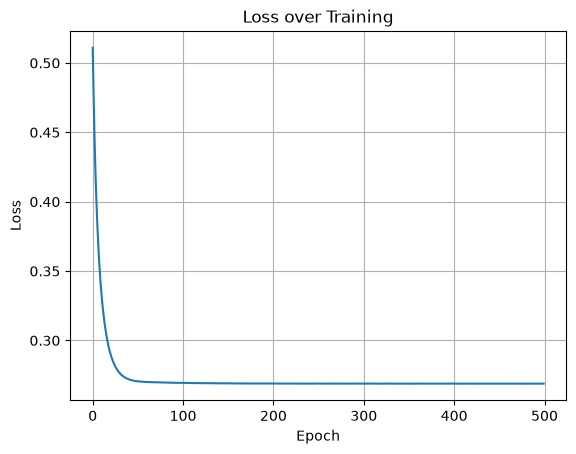

In [8]:
history = model.fit(X_train, y_train, epochs=500)

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title('Loss over Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()